# Task 3: Rigging and Lottery (RigL)

In the third task, students will implement a simplified version of Rigging the Lottery (RigL) [Evci et al.,
2020], which improves dynamic sparse training by using gradient information to guide the growth of new
connections. During topology updates:
- Remove weights with the smallest magnitude.
- Add new connections at locations with the largest gradient magnitude.

The intuition is that connections with large gradients would most effectively reduce the loss if they were active. We will compare RigL with both static sparse training and SET.

## 0. Setup and Data Loading

In [1]:
import gc
import os
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

In [2]:
# uncomment lines below if running on Colab and set MY_DRIVE_PATH to your drive path

from google.colab import drive

drive.mount("/content/drive")
MY_DRIVE_PATH = "/content/drive/MyDrive/ECE685D_Final_Project"  # <-- SET THIS


# ── Auto-detect project root (works locally and on Colab after setting above) ─
def _infer_project_dir(start=None):
    from pathlib import Path

    root = Path(start or os.getcwd()).resolve()
    for candidate in [root, *root.parents]:
        if (candidate / "models.py").exists() and (candidate / "results").exists():
            return str(candidate)
    return str(root)


try:
    PROJECT_DIR = MY_DRIVE_PATH  # Colab path wins if defined above
except NameError:
    PROJECT_DIR = _infer_project_dir()  # fall back to local detection

if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

os.makedirs(os.path.join(PROJECT_DIR, "results"), exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, "img"), exist_ok=True)

print(f"PROJECT_DIR : {PROJECT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR : /content/drive/MyDrive/ECE685D_Final_Project


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_pin_memory = torch.cuda.is_available()
num_workers = min(2, os.cpu_count() or 1)

print(f"Using device : {device}")

Using device : cuda


In [4]:
from models import ResNetCIFAR

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ]
)

trainset = torchvision.datasets.CIFAR10(
    root=os.path.join(PROJECT_DIR, "data"),
    train=True,
    download=True,
    transform=transform,
)
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=use_pin_memory,
)

testset = torchvision.datasets.CIFAR10(
    root=os.path.join(PROJECT_DIR, "data"),
    train=False,
    download=True,
    transform=transform,
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=128,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=use_pin_memory,
)

print(f"Loaded CIFAR-10 — {len(trainset)} train / {len(testset)} test samples.")

Loaded CIFAR-10 — 50000 train / 10000 test samples.


## 1. RigL Configuration

In [5]:
sparsity_levels = [0.90, 0.95, 0.98]
optimizers = ["sgd", "adam"]

# RigL-specific hyperparameters
prune_fraction = (
    0.20  # fraction of active weights pruned/grown per update (paper default)
)
rewire_interval = (
    1  # topology update every N epochs (simplified; paper uses fixed steps)
)
epochs = 15

criterion = nn.CrossEntropyLoss()
output_dir = os.path.join(PROJECT_DIR, "results")

print(f"Sparsity levels  : {sparsity_levels}")
print(f"Optimizers       : {optimizers}")
print(f"Prune fraction   : {prune_fraction}")
print(f"Rewire interval  : every {rewire_interval} epoch(s)")
print(f"Epochs           : {epochs}")
print(f"Output directory : {output_dir}")

Sparsity levels  : [0.9, 0.95, 0.98]
Optimizers       : ['sgd', 'adam']
Prune fraction   : 0.2
Rewire interval  : every 1 epoch(s)
Epochs           : 15
Output directory : /content/drive/MyDrive/ECE685D_Final_Project/results


## How RigL Works (Evci et al., 2020)

| Task | Method | Topology changes? | How new connections are chosen |
|------|--------|-------------------|-------------------------------|
| 1 | Static Sparse | Never | Random at init, frozen forever |
| 2 | SET | Every epoch | Randomly |
| 3 | **RigL** | **Every epoch** | **By gradient magnitude** |

The main thing that changes between SET and RigL is *which* dead connections get revived.

---

#### The core idea

A weight that is currently zero (i.e. pruned) still has a well-defined gradient. Even though $W_{ij} = 0$, the chain rule gives:

$$\frac{\partial \mathcal{L}}{\partial W_{ij}} = \delta_j \cdot a_i$$

where $\delta_j$ is the upstream error at neuron $j$ and $a_i$ is the activation of neuron $i$. This value is completely independent of $W_{ij}$ itself — it tells us *how much the loss would decrease if we turned this connection on*. A large magnitude means the connection would be immediately useful; a near-zero magnitude means it would barely matter.

RigL exploits this: instead of growing connections at random positions (SET), it grows them at the positions where the gradient magnitude is largest.

---

#### The update rule (one topology step)

Let $\mathbf{M} \in \{0,1\}^n$ be the binary mask for a layer with $n$ total parameters. The effective weight tensor is $\mathbf{W}_{\text{eff}} = \mathbf{M} \odot \mathbf{W}$.

Define:
- $\mathcal{A} = \{i : M_i = 1\}$ — the set of **active** (live) connections
- $\mathcal{D} = \{i : M_i = 0\}$ — the set of **dead** (pruned) connections
- $\alpha \in (0, 1)$ — the fraction of active connections to swap each update (here $\alpha = 0.20$)
- $k = \lfloor |\mathcal{A}| \cdot \alpha \rfloor$ — number of connections to prune and grow

**Step 1 — Prune** (remove the $k$ weakest active connections by weight magnitude):

$$\mathcal{P} = \underset{i \in \mathcal{A},\; |\mathcal{P}|=k}{\arg\min} \; |W_i|$$

Set $M_i \leftarrow 0$ and $W_i \leftarrow 0$ for all $i \in \mathcal{P}$.

**Step 2 — Grow** (add the $k$ most promising dead connections by gradient magnitude):

$$\mathcal{G} = \underset{i \in \mathcal{D},\; |\mathcal{G}|=k}{\arg\max} \left| \frac{\partial \mathcal{L}}{\partial W_i} \right|$$

Set $M_i \leftarrow 1$ and $W_i \leftarrow 0$ for all $i \in \mathcal{G}$.

Newly grown weights start at zero. Their gradients are already non-zero, so the optimizer will move them in the right direction on the very next training step.

---

#### Why this improves over SET

SET selects new connections uniformly at random from $\mathcal{D}$, so it has no way of knowing which dead connections are actually useful. RigL selects the $k$ positions from $\mathcal{D}$ with the largest $|\partial \mathcal{L}/\partial W_i|$, so every topology update is *informed by the current loss landscape*. Over many update steps, the network converges to a sparse topology that is much better matched to the data than a random one.

---

#### What the code below implements

The helper functions below mirror this algorithm directly:

- `initialize_masks` — creates $\mathbf{M}$ by sampling a Bernoulli mask at the target sparsity
- `apply_masks` — enforces $\mathbf{W}_{\text{eff}} = \mathbf{M} \odot \mathbf{W}$ after each optimizer step
- `apply_masks_to_grads` — zeroes gradients at dead positions during normal training so the optimizer doesn't accidentally update them
- `rigl_update` — implements Steps 1 and 2 above; uses a dedicated mini-batch forward/backward pass to get clean gradients at dead positions (before `apply_masks_to_grads` can zero them)

## 2. Helper Functions

In [6]:
def initialize_masks(model, sparsity):
    """Initialize binary masks based on target sparsity."""
    masks = {}
    for name, param in model.named_parameters():
        if "weight" in name and param.ndim > 1:
            masks[name] = (torch.rand_like(param) > sparsity).float()
    return masks


def apply_masks(model, masks):
    """Zero out pruned weights in-place."""
    with torch.no_grad():
        for name, param in model.named_parameters():
            if name in masks:
                param.mul_(masks[name])


def apply_masks_to_grads(model, masks):
    """Prevent pruned connections from receiving gradient updates."""
    for name, param in model.named_parameters():
        if name in masks and param.grad is not None:
            param.grad.mul_(masks[name])


def rigl_update(model, masks, prune_fraction, dataloader, criterion, device):
    """
    RigL topology update (Evci et al., 2020).

    For each sparse layer:
      1. Prune the `prune_fraction` of currently active weights with the
         smallest magnitude.
      2. Grow the same number of new connections at the inactive positions
         with the largest gradient magnitude.

    Gradient magnitudes at inactive (zero) positions are meaningful:
    even though the weight is 0, the backprop gradient there equals the
    upstream error times the input activation — i.e., exactly how much the
    loss would benefit if that connection were turned on.  We capture these
    gradients via a dedicated mini-batch forward/backward pass (no optimizer
    step), so they are never zeroed by apply_masks_to_grads.

    Newly grown weights are initialised to 0 (as in the paper); the
    optimizer will immediately start moving them in the right direction.
    """
    model.train()
    inputs, labels = next(iter(dataloader))
    inputs, labels = inputs.to(device), labels.to(device)

    model.zero_grad()
    loss = criterion(model(inputs), labels)
    loss.backward()  # gradients exist at ALL positions, including zeros

    with torch.no_grad():
        for name, param in model.named_parameters():
            if name not in masks or param.grad is None:
                continue

            mask = masks[name]
            grad = param.grad.detach()

            active_pos = mask.nonzero(as_tuple=False)
            if active_pos.numel() == 0:
                continue

            n_update = int(active_pos.size(0) * prune_fraction)
            if n_update < 1:
                continue

            # 1. Prune: smallest-magnitude active weights
            active_vals = param[mask.bool()].abs()
            _, prune_local_idx = torch.topk(active_vals, k=n_update, largest=False)
            prune_pos = active_pos[prune_local_idx]
            prune_idx = tuple(prune_pos[:, d] for d in range(prune_pos.size(1)))

            mask[prune_idx] = 0.0
            param[prune_idx] = 0.0

            # 2. Grow: largest-|gradient| inactive weights
            inactive_pos = (mask == 0).nonzero(as_tuple=False)
            if inactive_pos.numel() == 0:
                continue

            inactive_idx = tuple(
                inactive_pos[:, d] for d in range(inactive_pos.size(1))
            )
            inactive_grad = grad[inactive_idx].abs()

            n_grow = min(n_update, inactive_pos.size(0))
            _, grow_local_idx = torch.topk(inactive_grad, k=n_grow, largest=True)
            grow_pos = inactive_pos[grow_local_idx]
            grow_idx = tuple(grow_pos[:, d] for d in range(grow_pos.size(1)))

            mask[grow_idx] = 1.0
            param[grow_idx] = 0.0  # initialize new connections to zero

    model.zero_grad()


def build_sparse_model(sparsity):
    model = ResNetCIFAR().to(device)
    masks = initialize_masks(model, sparsity)
    apply_masks(model, masks)
    return model, masks


def build_optimizer(model, optimizer_type):
    if optimizer_type == "sgd":
        return optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    if optimizer_type == "adam":
        return optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
    raise ValueError(f"Unsupported optimizer: {optimizer_type}")


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            total_loss += criterion(outputs, labels).item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return total_loss / len(loader), 100.0 * correct / total

## 3. Train and Save Results

In [7]:
all_results = {}

for opt_name in optimizers:
    all_results[opt_name] = {}
    for target_sparsity in sparsity_levels:
        print(
            f"\n===== RigL | Sparsity={target_sparsity:.2f} | Optimizer={opt_name} ====="
        )

        model, masks = build_sparse_model(target_sparsity)
        optimizer = build_optimizer(model, opt_name)
        history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

        for epoch in range(epochs):
            # Training
            model.train()
            running_loss, correct, total = 0.0, 0, 0

            for inputs, labels in trainloader:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()

                apply_masks_to_grads(model, masks)  # freeze dead connections
                optimizer.step()
                apply_masks(model, masks)  # enforce sparsity

                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

            # RigL topology update
            if (epoch + 1) % rewire_interval == 0:
                rigl_update(
                    model, masks, prune_fraction, trainloader, criterion, device
                )
                apply_masks(model, masks)

            # Metrics
            total_active = sum(m.sum().item() for m in masks.values())
            total_possible = sum(m.numel() for m in masks.values())
            current_sparsity = 1.0 - total_active / total_possible

            train_loss = running_loss / len(trainloader)
            train_acc = 100.0 * correct / total
            test_loss, test_acc = evaluate(model, testloader, criterion)

            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)
            history["test_loss"].append(test_loss)
            history["test_acc"].append(test_acc)

            print(
                f"Epoch [{epoch+1:2d}/{epochs}] | "
                f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
                f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}% | "
                f"Sparsity: {current_sparsity:.4f}"
            )

        # Save
        experiment_results = {
            "sparsity": target_sparsity,
            "optimizer": opt_name,
            "method": "RigL",
            "prune_fraction": prune_fraction,
            "rewire_interval": rewire_interval,
            "epochs": epochs,
            "train_loss": history["train_loss"],
            "train_acc": history["train_acc"],
            "test_loss": history["test_loss"],
            "test_acc": history["test_acc"],
            "masks": masks,
            "model_state": model.state_dict(),
        }

        save_path = os.path.join(
            output_dir,
            f"task_3_{opt_name}_{int(target_sparsity * 100)}_sparsity.joblib",
        )
        joblib.dump(experiment_results, save_path)
        print(f"Saved → {save_path}")

        all_results[opt_name][target_sparsity] = experiment_results

print("\nFinished all RigL runs.")


===== RigL | Sparsity=0.90 | Optimizer=sgd =====
Epoch [ 1/15] | Train Loss: 1.5262 | Train Acc: 43.34% | Test Loss: 1.4596 | Test Acc: 46.79% | Sparsity: 0.9004
Epoch [ 2/15] | Train Loss: 1.1022 | Train Acc: 60.45% | Test Loss: 1.2061 | Test Acc: 57.40% | Sparsity: 0.9004
Epoch [ 3/15] | Train Loss: 0.9484 | Train Acc: 66.27% | Test Loss: 1.2907 | Test Acc: 56.03% | Sparsity: 0.9004
Epoch [ 4/15] | Train Loss: 0.8500 | Train Acc: 69.99% | Test Loss: 1.6463 | Test Acc: 42.82% | Sparsity: 0.9004
Epoch [ 5/15] | Train Loss: 0.8066 | Train Acc: 71.85% | Test Loss: 1.9401 | Test Acc: 35.26% | Sparsity: 0.9004
Epoch [ 6/15] | Train Loss: 0.7685 | Train Acc: 73.10% | Test Loss: 4.6854 | Test Acc: 13.54% | Sparsity: 0.9004
Epoch [ 7/15] | Train Loss: 0.7783 | Train Acc: 72.99% | Test Loss: 3.4164 | Test Acc: 15.07% | Sparsity: 0.9004
Epoch [ 8/15] | Train Loss: 0.7690 | Train Acc: 73.28% | Test Loss: 1.1495 | Test Acc: 62.79% | Sparsity: 0.9004
Epoch [ 9/15] | Train Loss: 0.7099 | Train Acc

## 4. Analysis and Comparison

This section loads all saved artifacts (Tasks 1, 2, and 3) and produces:
- Training dynamics for RigL across sparsity levels
- Final test accuracy vs. sparsity for RigL
- Three-way comparison: Static Sparse (Task 1) vs. SET (Task 2) vs. RigL (Task 3)

In [8]:
%matplotlib inline

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.autolayout"] = True

# Patch torch.load so GPU-saved artifacts load on CPU
_orig_load = torch.serialization.load
def _cpu_load(*args, **kwargs):
    kwargs["map_location"] = torch.device("cpu")
    return _orig_load(*args, **kwargs)
torch.load = _cpu_load

analysis_sparsities = [0.90, 0.95, 0.98]
analysis_opts       = ["sgd", "adam"]
analysis_dir        = os.path.join(PROJECT_DIR, "results")
img_dir             = os.path.join(PROJECT_DIR, "img")

def load_task_results(task_id, opts, sparsities, results_dir):
    results = {opt: {} for opt in opts}
    for opt in opts:
        for s in sparsities:
            path = os.path.join(results_dir, f"task_{task_id}_{opt}_{int(s*100)}_sparsity.joblib")
            if not os.path.exists(path):
                print(f"  Missing: {path}")
                continue
            try:
                results[opt][s] = joblib.load(path, mmap_mode=None)
                print(f"  Loaded : {path}")
            except Exception as e:
                print(f"  Failed : {path} — {e}")
    return results

print("Loading Task 1 (Static Sparse)…")
results_task_1 = load_task_results(1, analysis_opts, analysis_sparsities, analysis_dir)

print("\nLoading Task 2 (SET)…")
results_task_2 = load_task_results(2, analysis_opts, analysis_sparsities, analysis_dir)

print("\nLoading Task 3 (RigL)…")
results_task_3 = load_task_results(3, analysis_opts, analysis_sparsities, analysis_dir)

print("\nAll artifacts loaded.")

Loading Task 1 (Static Sparse)…
  Loaded : /content/drive/MyDrive/ECE685D_Final_Project/results/task_1_sgd_90_sparsity.joblib
  Loaded : /content/drive/MyDrive/ECE685D_Final_Project/results/task_1_sgd_95_sparsity.joblib
  Loaded : /content/drive/MyDrive/ECE685D_Final_Project/results/task_1_sgd_98_sparsity.joblib
  Loaded : /content/drive/MyDrive/ECE685D_Final_Project/results/task_1_adam_90_sparsity.joblib
  Loaded : /content/drive/MyDrive/ECE685D_Final_Project/results/task_1_adam_95_sparsity.joblib
  Loaded : /content/drive/MyDrive/ECE685D_Final_Project/results/task_1_adam_98_sparsity.joblib

Loading Task 2 (SET)…
  Loaded : /content/drive/MyDrive/ECE685D_Final_Project/results/task_2_sgd_90_sparsity.joblib
  Loaded : /content/drive/MyDrive/ECE685D_Final_Project/results/task_2_sgd_95_sparsity.joblib
  Loaded : /content/drive/MyDrive/ECE685D_Final_Project/results/task_2_sgd_98_sparsity.joblib
  Loaded : /content/drive/MyDrive/ECE685D_Final_Project/results/task_2_adam_90_sparsity.joblib
 

### Training Dynamics (Task 3 — RigL)

Four subplots per sparsity level: train/test loss and train/test accuracy, comparing SGD vs Adam.

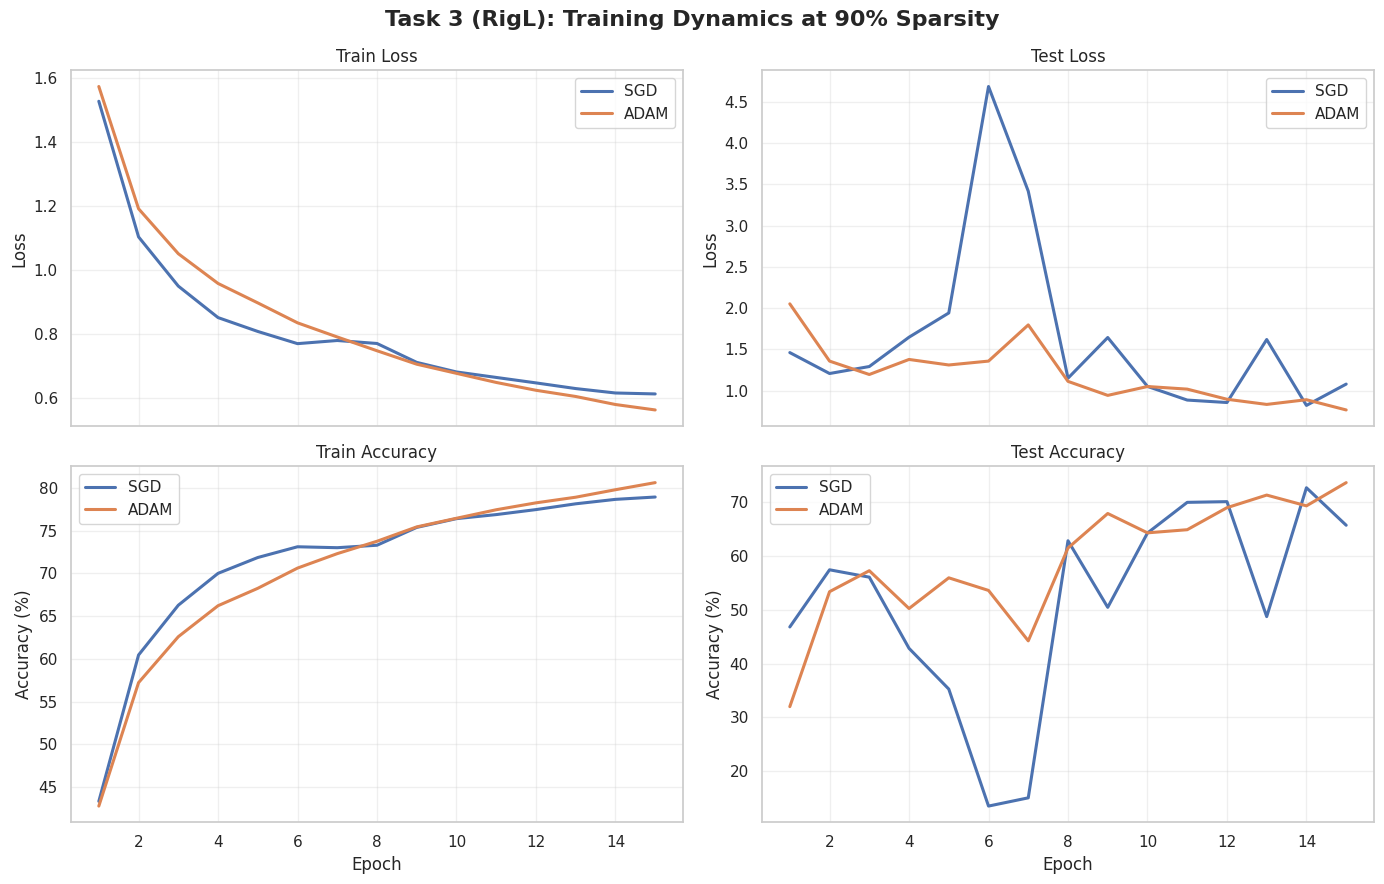

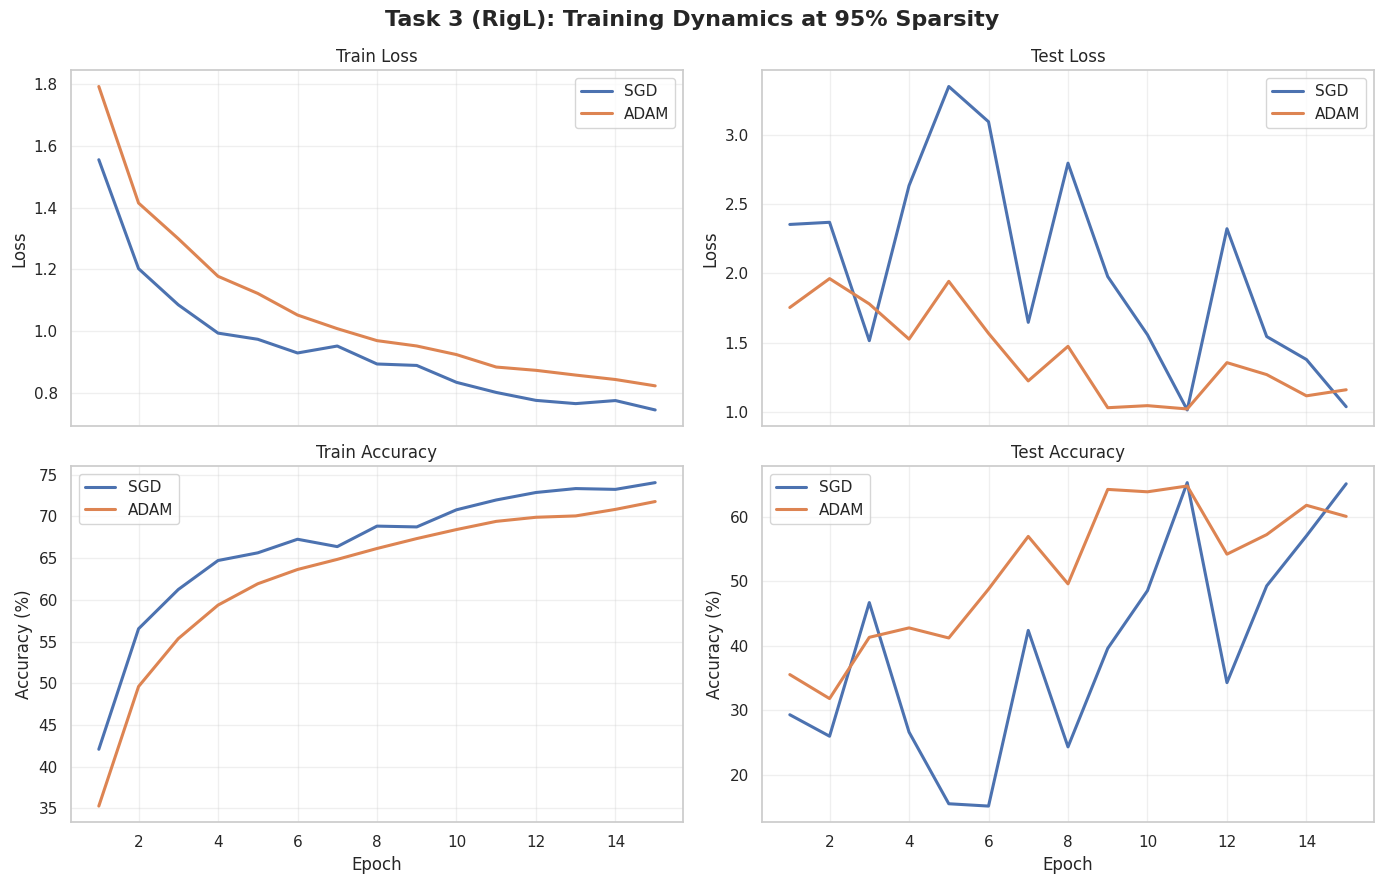

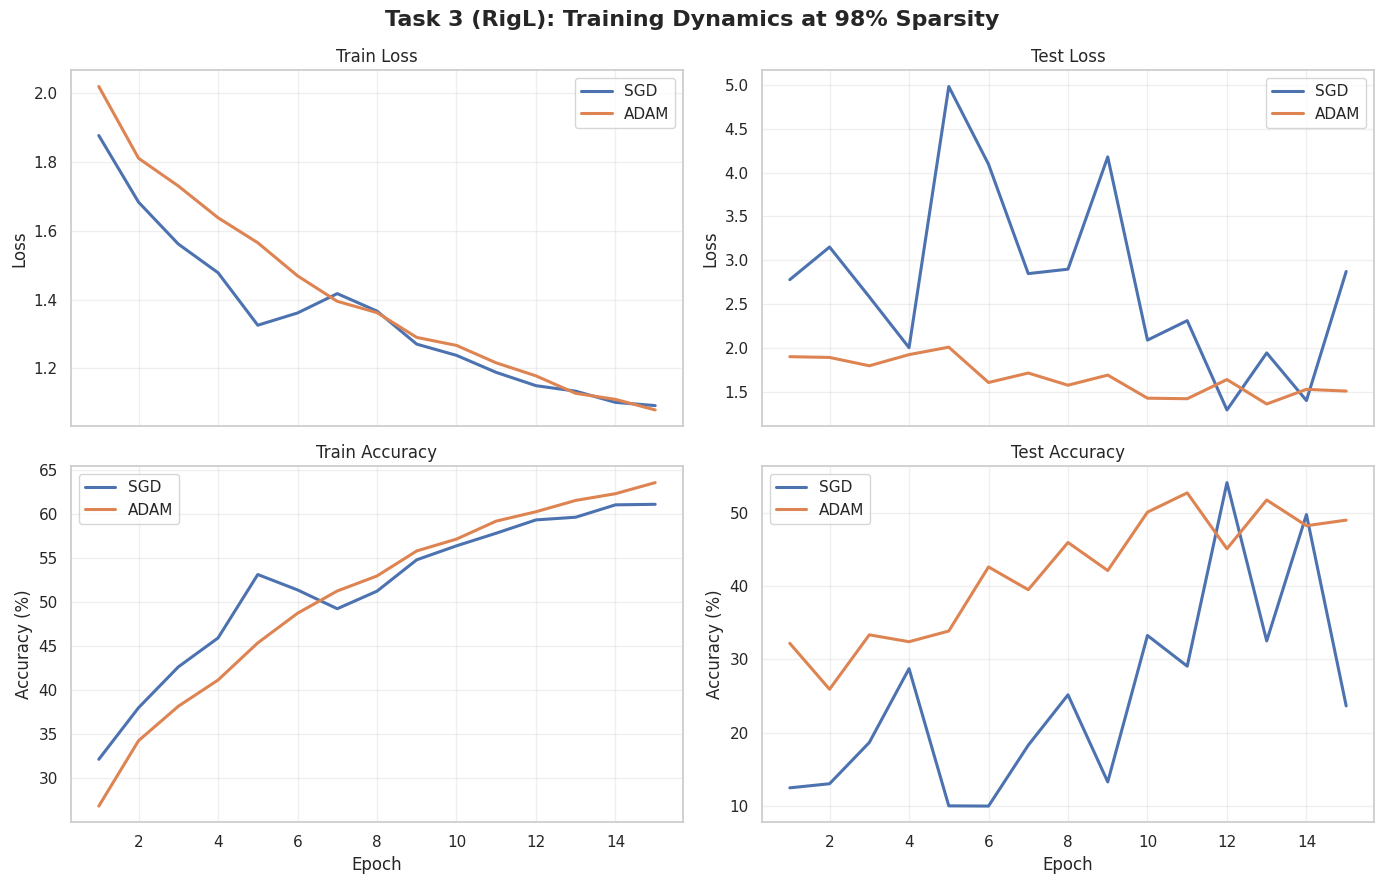

Training dynamics done.


In [9]:
def plot_training_dynamics(results, task_label="Task 3 (RigL)"):
    for s in analysis_sparsities:
        rows = []
        for opt in analysis_opts:
            if s not in results.get(opt, {}):
                continue
            n = len(results[opt][s]["train_loss"])
            for epoch in range(n):
                for split in ("Train", "Test"):
                    key_loss = f"{split.lower()}_loss"
                    key_acc = f"{split.lower()}_acc"
                    rows.append(
                        {
                            "epoch": epoch + 1,
                            "optimizer": opt.upper(),
                            "split": split,
                            "loss": results[opt][s][key_loss][epoch],
                            "accuracy": results[opt][s][key_acc][epoch],
                        }
                    )

        if not rows:
            print(f"No data for sparsity={s:.2f}")
            continue

        df = pd.DataFrame(rows)

        fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
        fig.suptitle(
            f"{task_label}: Training Dynamics at {int(s * 100)}% Sparsity",
            fontsize=16,
            weight="bold",
        )

        for row, col, split, metric, ylabel in [
            (0, 0, "Train", "loss", "Loss"),
            (0, 1, "Test", "loss", "Loss"),
            (1, 0, "Train", "accuracy", "Accuracy (%)"),
            (1, 1, "Test", "accuracy", "Accuracy (%)"),
        ]:
            title = f"{'Train' if split == 'Train' else 'Test'} {metric.capitalize()}"
            sns.lineplot(
                data=df[df["split"] == split],
                x="epoch",
                y=metric,
                hue="optimizer",
                linewidth=2.2,
                ax=axes[row, col],
            )
            axes[row, col].set_title(title)
            axes[row, col].set_ylabel(ylabel)
            axes[row, col].legend(title="")
            if row == 1:
                axes[row, col].set_xlabel("Epoch")

        for ax in axes.flat:
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(
            os.path.join(img_dir, f"task_3_curves_{int(s * 100)}.png"),
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()


plot_training_dynamics(results_task_3, task_label="Task 3 (RigL)")
gc.collect()
print("Training dynamics done.")

### Final Accuracy vs. Sparsity (Task 3 — RigL)

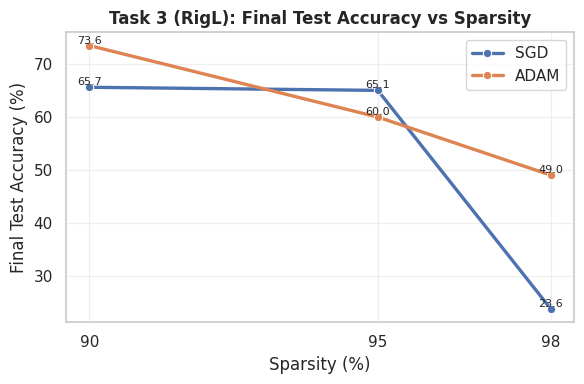

Accuracy vs. sparsity done.


In [10]:
def plot_accuracy_vs_sparsity(
    results, task_label="Task 3 (RigL)", save_name="task_3_accuracy_vs_sparsity.png"
):
    rows = []
    for opt in analysis_opts:
        for s in analysis_sparsities:
            if s in results.get(opt, {}):
                rows.append(
                    {
                        "optimizer": opt.upper(),
                        "sparsity": int(s * 100),
                        "final_test_acc": results[opt][s]["test_acc"][-1],
                    }
                )

    if not rows:
        print("No data available.")
        return None

    df = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.lineplot(
        data=df,
        x="sparsity",
        y="final_test_acc",
        hue="optimizer",
        marker="o",
        linewidth=2.4,
        ax=ax,
    )

    for _, row in df.iterrows():
        ax.text(
            row["sparsity"],
            row["final_test_acc"],
            f"{row['final_test_acc']:.1f}",
            fontsize=8,
            ha="center",
            va="bottom",
        )

    ax.set_title(f"{task_label}: Final Test Accuracy vs Sparsity", weight="bold")
    ax.set_xlabel("Sparsity (%)")
    ax.set_ylabel("Final Test Accuracy (%)")
    ax.set_xticks([90, 95, 98])
    ax.legend(title="")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(img_dir, save_name), dpi=300, bbox_inches="tight")
    plt.show()

    return df.sort_values(["optimizer", "sparsity"]).reset_index(drop=True)


task3_summary = plot_accuracy_vs_sparsity(results_task_3)
gc.collect()
print("Accuracy vs. sparsity done.")

### Three-Way Comparison: Static Sparse vs. SET vs. RigL

Grouped bar chart of final test accuracy across all three methods and sparsity levels, plus a heatmap of RigL's gain/loss over each baseline.

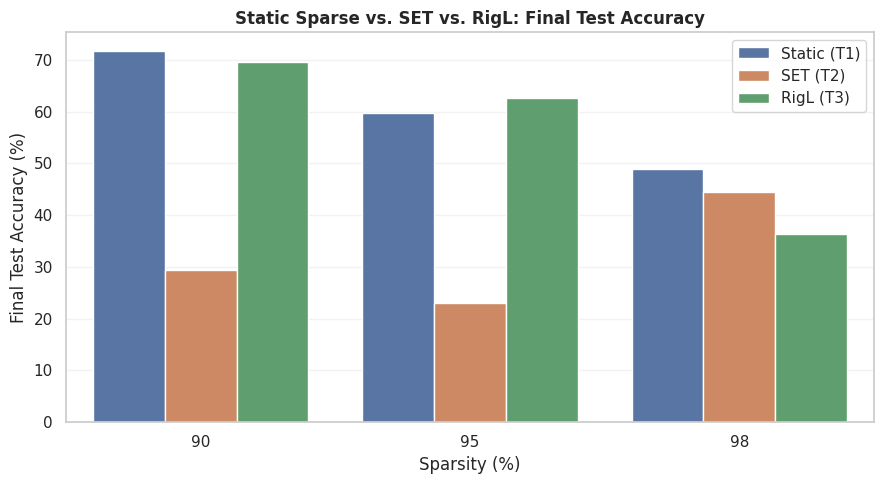

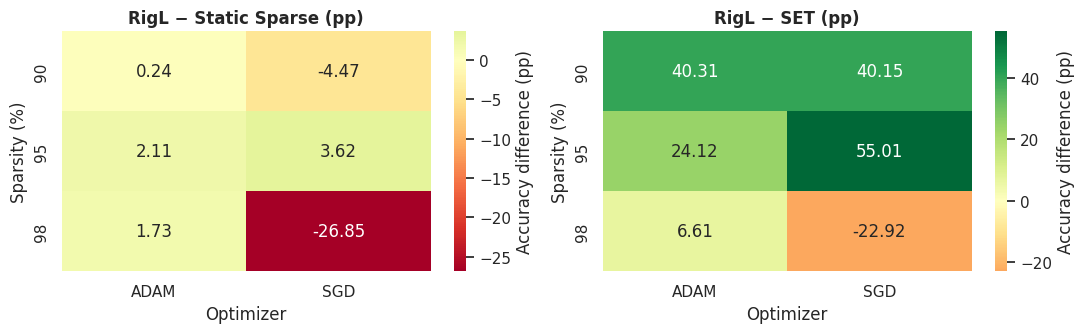

Three-way comparison done.


In [11]:
def compare_all_methods(res_t1, res_t2, res_t3):
    rows = []
    for opt in analysis_opts:
        for s in analysis_sparsities:
            t1 = res_t1.get(opt, {}).get(s, {}).get("test_acc", [])
            t2 = res_t2.get(opt, {}).get(s, {}).get("test_acc", [])
            t3 = res_t3.get(opt, {}).get(s, {}).get("test_acc", [])
            if not (t1 and t2 and t3):
                continue
            rows.append(
                {
                    "optimizer": opt.upper(),
                    "sparsity": int(s * 100),
                    "task_1_static": t1[-1],
                    "task_2_set": t2[-1],
                    "task_3_rigl": t3[-1],
                    "delta_rigl_vs_static": t3[-1] - t1[-1],
                    "delta_rigl_vs_set": t3[-1] - t2[-1],
                }
            )

    if not rows:
        print("No overlapping results across all three tasks.")
        return None

    df = (
        pd.DataFrame(rows).sort_values(["optimizer", "sparsity"]).reset_index(drop=True)
    )

    # Grouped bar chart
    long_df = df.melt(
        id_vars=["optimizer", "sparsity"],
        value_vars=["task_1_static", "task_2_set", "task_3_rigl"],
        var_name="method",
        value_name="final_test_acc",
    )
    long_df["method"] = long_df["method"].map(
        {
            "task_1_static": "Static (T1)",
            "task_2_set": "SET (T2)",
            "task_3_rigl": "RigL (T3)",
        }
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(
        data=long_df,
        x="sparsity",
        y="final_test_acc",
        hue="method",
        errorbar=None,
        ax=ax,
    )
    ax.set_title("Static Sparse vs. SET vs. RigL: Final Test Accuracy", weight="bold")
    ax.set_xlabel("Sparsity (%)")
    ax.set_ylabel("Final Test Accuracy (%)")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(title="")
    plt.tight_layout()
    plt.savefig(
        os.path.join(img_dir, "task_3_all_methods_accuracy.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

    # Heatmap: RigL gain over Static
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

    for ax, delta_col, title in [
        (axes[0], "delta_rigl_vs_static", "RigL − Static Sparse (pp)"),
        (axes[1], "delta_rigl_vs_set", "RigL − SET (pp)"),
    ]:
        pivot = df.pivot(index="sparsity", columns="optimizer", values=delta_col)
        sns.heatmap(
            pivot,
            annot=True,
            fmt=".2f",
            cmap="RdYlGn",
            center=0,
            cbar_kws={"label": "Accuracy difference (pp)"},
            ax=ax,
        )
        ax.set_title(title, weight="bold")
        ax.set_xlabel("Optimizer")
        ax.set_ylabel("Sparsity (%)")

    plt.tight_layout()
    plt.savefig(
        os.path.join(img_dir, "task_3_delta_heatmaps.png"), dpi=300, bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)

    return df


comparison_df = compare_all_methods(results_task_1, results_task_2, results_task_3)
gc.collect()
print("Three-way comparison done.")

### Summary Tables

In [12]:
print("=" * 65)
print("TASK 3 (RigL) — Final Test Accuracy")
print("=" * 65)
if task3_summary is not None:
    display(task3_summary)

print("\n" + "=" * 65)
print("THREE-WAY COMPARISON (final test accuracy, %)")
print("=" * 65)
if comparison_df is not None:
    display(
        comparison_df[
            [
                "optimizer",
                "sparsity",
                "task_1_static",
                "task_2_set",
                "task_3_rigl",
                "delta_rigl_vs_static",
                "delta_rigl_vs_set",
            ]
        ]
    )

    print("\nAverage delta — RigL vs. Static Sparse, by optimizer:")
    display(
        comparison_df.groupby("optimizer", as_index=False)[
            "delta_rigl_vs_static"
        ].mean()
    )

    print("\nAverage delta — RigL vs. SET, by optimizer:")
    display(
        comparison_df.groupby("optimizer", as_index=False)["delta_rigl_vs_set"].mean()
    )

    best = comparison_df.loc[comparison_df["task_3_rigl"].idxmax()]
    worst = comparison_df.loc[comparison_df["task_3_rigl"].idxmin()]
    print(
        f"\nBest  RigL setting: {best['optimizer']} @ {best['sparsity']}% → {best['task_3_rigl']:.2f}%"
    )
    print(
        f"Worst RigL setting: {worst['optimizer']} @ {worst['sparsity']}% → {worst['task_3_rigl']:.2f}%"
    )

print("Analysis pipeline complete.")

TASK 3 (RigL) — Final Test Accuracy


,optimizer,sparsity,final_test_acc
0,ADAM,90,73.58
1,ADAM,95,60.03
2,ADAM,98,49.01
3,SGD,90,65.67
4,SGD,95,65.08
5,SGD,98,23.65



THREE-WAY COMPARISON (final test accuracy, %)


,optimizer,sparsity,task_1_static,task_2_set,task_3_rigl,delta_rigl_vs_static,delta_rigl_vs_set
0,ADAM,90,73.34,33.27,73.58,0.24,40.31
1,ADAM,95,57.92,35.91,60.03,2.11,24.12
2,ADAM,98,47.28,42.40,49.01,1.73,6.61
3,SGD,90,70.14,25.52,65.67,-4.47,40.15
4,SGD,95,61.46,10.07,65.08,3.62,55.01
5,SGD,98,50.50,46.57,23.65,-26.85,-22.92



Average delta — RigL vs. Static Sparse, by optimizer:


,optimizer,delta_rigl_vs_static
0,ADAM,1.360000
1,SGD,-9.233333



Average delta — RigL vs. SET, by optimizer:


,optimizer,delta_rigl_vs_set
0,ADAM,23.68
1,SGD,24.08



Best  RigL setting: ADAM @ 90% → 73.58%
Worst RigL setting: SGD @ 98% → 23.65%
Analysis pipeline complete.


## 5. Per-Layer Sparsity Analysis

The project requires reporting sparsity statistics broken down by network component, not just as a single overall number. Here we group layers into five stages (stem conv, layer1, layer2, layer3, and the final FC layer) and compare how each method distributes sparsity across those stages. Static sparse training initializes masks randomly and never changes them, so sparsity is uniform across stages by construction. SET and RigL both move weights around during training, so their per-stage sparsity can drift away from the uniform target.

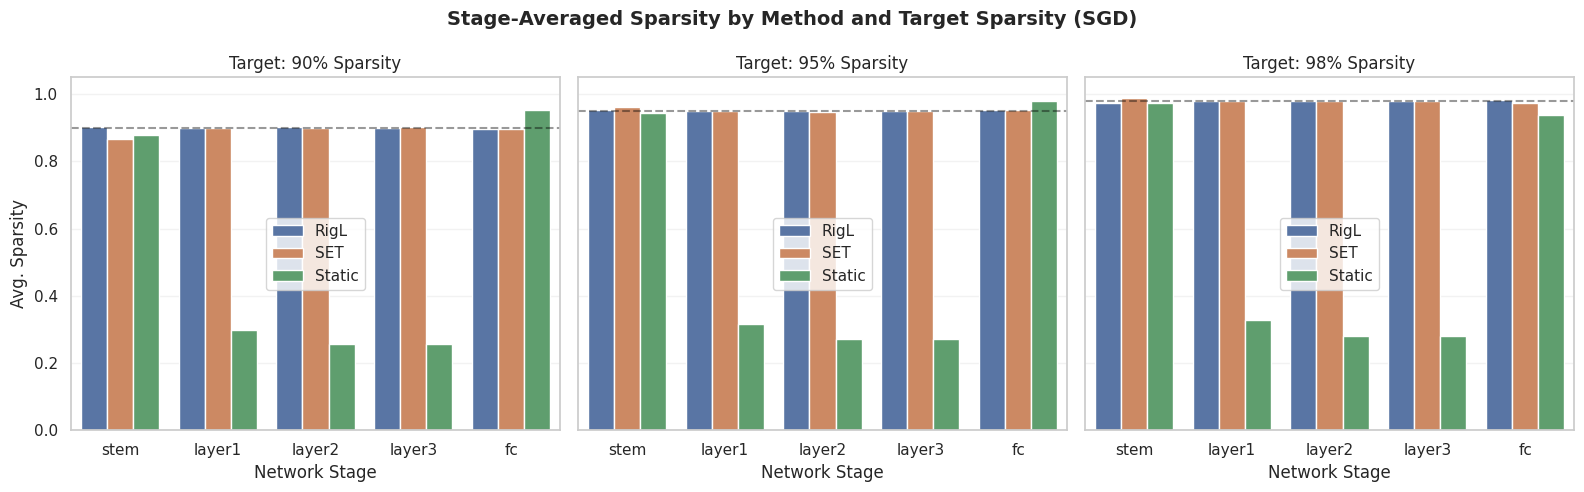

RigL SGD 90% — per-layer sparsity breakdown:


,layer,stage,params,sparsity
0,conv1,stem,432,0.9028
1,layer1.0.conv1,layer1,2304,0.9058
2,layer1.0.conv2,layer1,2304,0.8924
3,layer1.1.conv1,layer1,2304,0.9002
4,layer1.1.conv2,layer1,2304,0.9015
5,layer1.2.conv1,layer1,2304,0.9036
6,layer1.2.conv2,layer1,2304,0.9006
7,layer2.0.conv1,layer2,4608,0.9047
8,layer2.0.conv2,layer2,9216,0.9018
9,layer2.0.shortcut.0,layer2,512,0.9160


In [13]:
def get_stage(name):
    """Map a layer parameter name to its network stage."""
    n = name.replace(".weight", "")
    if n == "conv1":
        return "stem"
    for s in ("layer1", "layer2", "layer3"):
        if n.startswith(s):
            return s
    if n.startswith("linear"):
        return "fc"
    return "other"


def per_layer_sparsity_rows(results_dict, task_label):
    rows = []
    for opt in analysis_opts:
        for s in analysis_sparsities:
            res = results_dict.get(opt, {}).get(s)
            if res is None or "masks" not in res:
                continue
            for name, mask in res["masks"].items():
                m = mask.cpu()
                sp = 1.0 - m.sum().item() / m.numel()
                rows.append(
                    {
                        "method": task_label,
                        "optimizer": opt.upper(),
                        "target_sparsity": int(s * 100),
                        "layer": name.replace(".weight", ""),
                        "stage": get_stage(name),
                        "sparsity": sp,
                        "params": m.numel(),
                    }
                )
    return rows


all_rows = []
for label, rdict in [
    ("Static", results_task_1),
    ("SET", results_task_2),
    ("RigL", results_task_3),
]:
    all_rows.extend(per_layer_sparsity_rows(rdict, label))

layer_sparsity_df = pd.DataFrame(all_rows)

# Average sparsity per stage across methods, optimizers, and target sparsities
stage_df = (
    layer_sparsity_df.groupby(["method", "optimizer", "target_sparsity", "stage"])[
        "sparsity"
    ]
    .mean()
    .reset_index()
)

# One chart per target sparsity, comparing all three methods at each network stage (SGD only)
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle(
    "Stage-Averaged Sparsity by Method and Target Sparsity (SGD)",
    fontsize=14,
    weight="bold",
)

stage_order = ["stem", "layer1", "layer2", "layer3", "fc"]
for ax, s_val in zip(axes, [90, 95, 98]):
    sub = stage_df[
        (stage_df["optimizer"] == "SGD") & (stage_df["target_sparsity"] == s_val)
    ]
    sns.barplot(
        data=sub,
        x="stage",
        y="sparsity",
        hue="method",
        order=stage_order,
        ax=ax,
        errorbar=None,
    )
    ax.axhline(y=s_val / 100, color="black", linestyle="--", alpha=0.4)
    ax.set_title(f"Target: {s_val}% Sparsity")
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Network Stage")
    ax.set_ylabel("Avg. Sparsity" if ax is axes[0] else "")
    ax.legend(title="")
    ax.grid(True, axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig(
    os.path.join(img_dir, "task_3_layer_sparsity_by_stage.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()
gc.collect()

# Detailed per-layer breakdown for RigL SGD 90% as a reference table
detail = (
    layer_sparsity_df[
        (layer_sparsity_df["method"] == "RigL")
        & (layer_sparsity_df["optimizer"] == "SGD")
        & (layer_sparsity_df["target_sparsity"] == 90)
    ][["layer", "stage", "params", "sparsity"]]
    .sort_values("layer")
    .reset_index(drop=True)
)
detail["sparsity"] = detail["sparsity"].round(4)
print("RigL SGD 90% — per-layer sparsity breakdown:")
display(detail)

### Convolution Kernel Visualization

Visualizing the first convolutional layer (stem, 16 filters of size 3×3) shows how sparsity physically manifests inside a trained layer. Each patch is the filter averaged over input channels — red/blue indicates positive/negative weights, and white means the weight was pruned to zero. At 90% sparsity, most cells in each filter are white, so the few surviving active weights stand out clearly. Comparing across methods reveals whether gradient-guided growth (RigL) produces more structured filter patterns than random growth (SET) or fixed random masks (Static).

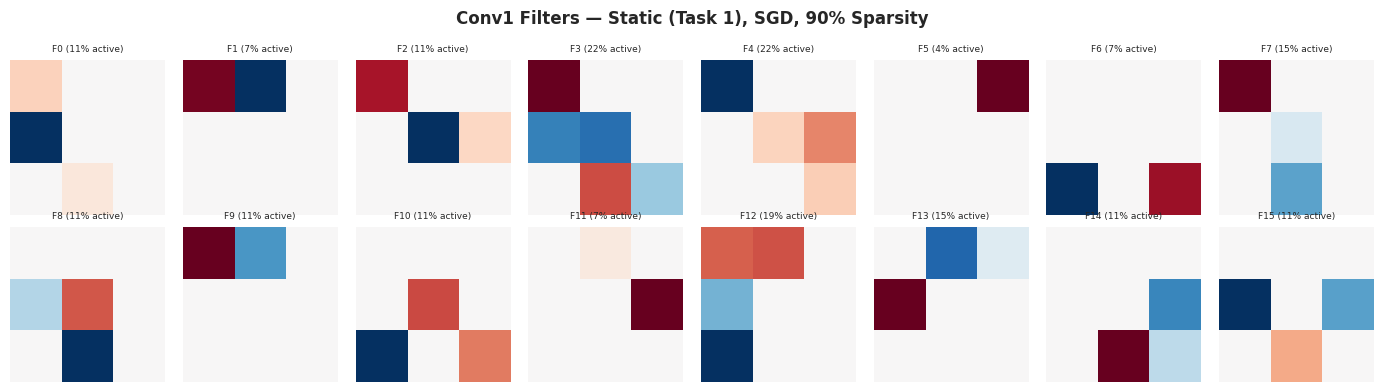

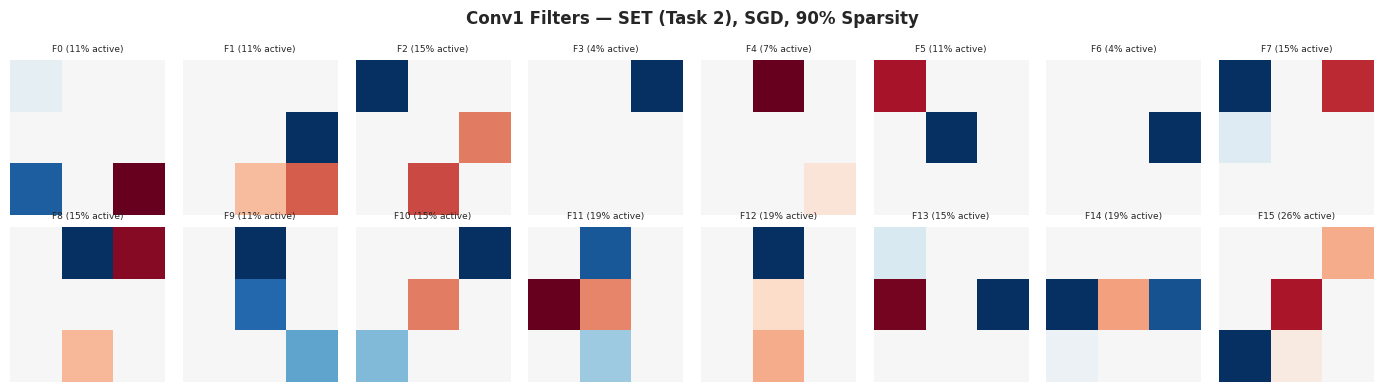

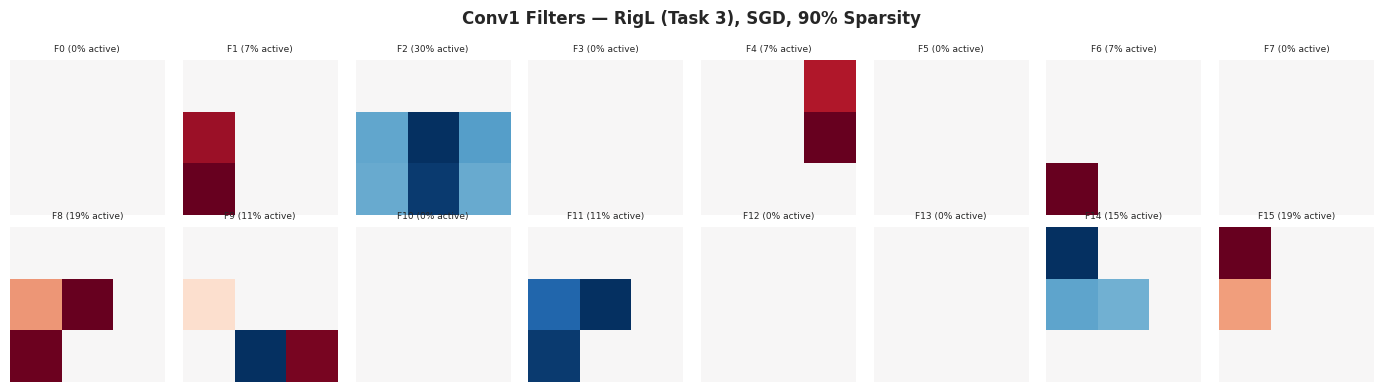

Kernel visualizations done.


In [14]:
def plot_conv1_kernels(model_state, masks, title):
    """Display all 16 stem conv filters as a 2x8 grid.
    Each patch is the filter averaged over input (RGB) channels, so red/blue = positive/negative
    weights and white = zero (pruned)."""
    w = model_state["conv1.weight"].cpu()  # [16, 3, 3, 3]
    mask = masks.get("conv1.weight")
    if mask is not None:
        w = w * mask.cpu()

    fig, axes = plt.subplots(2, 8, figsize=(14, 4))
    fig.suptitle(title, fontsize=12, weight="bold")

    for i, ax in enumerate(axes.flat):
        kernel = w[i].mean(0).numpy()  # average over RGB → [3, 3]
        vmax = max(float(abs(kernel).max()), 1e-6)
        ax.imshow(kernel, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        active_pct = 100.0 * (w[i].abs() > 1e-8).float().mean().item()
        ax.set_title(f"F{i} ({active_pct:.0f}% active)", fontsize=6.5)
        ax.axis("off")

    plt.tight_layout()


for method_label, rdict in [
    ("Static (Task 1)", results_task_1),
    ("SET (Task 2)", results_task_2),
    ("RigL (Task 3)", results_task_3),
]:
    res = rdict.get("sgd", {}).get(0.90)
    if res is None:
        continue
    plot_conv1_kernels(
        res["model_state"],
        res["masks"],
        f"Conv1 Filters — {method_label}, SGD, 90% Sparsity",
    )
    fname = f"task_3_kernels_{method_label.split()[0].lower()}_sgd_90.png"
    plt.savefig(os.path.join(img_dir, fname), dpi=300, bbox_inches="tight")
    plt.show()

gc.collect()
print("Kernel visualizations done.")

## 6. Connectivity Evolution During Training

For dynamic methods like RigL, the sparse topology is not fixed — connections are pruned and regrown every epoch. Because each update removes exactly as many connections as it adds, overall sparsity stays constant by construction. The more informative quantity is the **topology change rate**: what fraction of connections in each network stage are rewired (flipped on or off) after each update. A high change rate early in training means the network is still searching for a good sparse structure; a declining rate signals that the topology is stabilizing. Gradient-guided growth (RigL) should converge faster and to a lower change rate than random growth (SET).

In [15]:
# Re-run RigL SGD 90% tracking per-stage topology change rate each epoch.
# Change rate = fraction of connections flipped (0->1 or 1->0) by the update.

torch.manual_seed(42)
evo_model, evo_masks = build_sparse_model(0.90)
evo_optimizer = build_optimizer(evo_model, "sgd")
evo_history = []

for epoch in range(epochs):
    evo_model.train()
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        evo_optimizer.zero_grad()
        loss = criterion(evo_model(inputs), labels)
        loss.backward()
        apply_masks_to_grads(evo_model, evo_masks)
        evo_optimizer.step()
        apply_masks(evo_model, evo_masks)

    # Snapshot masks before topology update
    masks_before = {name: mask.clone() for name, mask in evo_masks.items()}

    if (epoch + 1) % rewire_interval == 0:
        rigl_update(
            evo_model, evo_masks, prune_fraction, trainloader, criterion, device
        )
        apply_masks(evo_model, evo_masks)

    # Compute per-stage change rate
    stage_changed = {}
    stage_total = {}
    for name, mask in evo_masks.items():
        stage = get_stage(name)
        flipped = (mask.cpu() != masks_before[name].cpu()).float().sum().item()
        stage_changed[stage] = stage_changed.get(stage, 0.0) + flipped
        stage_total[stage] = stage_total.get(stage, 0) + mask.numel()

    record = {"epoch": epoch + 1}
    for stage in stage_changed:
        record[stage] = round(stage_changed[stage] / stage_total[stage], 4)
    evo_history.append(record)

    print(
        f"Epoch {epoch + 1:2d}/{epochs} — "
        + "  ".join(f"{k}: {v:.4f}" for k, v in record.items() if k != "epoch")
    )

evo_df = pd.DataFrame(evo_history).set_index("epoch")
print("\nRigL connectivity evolution run complete.")

Epoch  1/15 — stem: 0.0509  layer1: 0.0391  layer2: 0.0381  layer3: 0.0388  fc: 0.0437
Epoch  2/15 — stem: 0.0509  layer1: 0.0392  layer2: 0.0382  layer3: 0.0388  fc: 0.0437
Epoch  3/15 — stem: 0.0509  layer1: 0.0378  layer2: 0.0378  layer3: 0.0387  fc: 0.0437
Epoch  4/15 — stem: 0.0509  layer1: 0.0388  layer2: 0.0379  layer3: 0.0386  fc: 0.0375
Epoch  5/15 — stem: 0.0509  layer1: 0.0391  layer2: 0.0376  layer3: 0.0384  fc: 0.0437
Epoch  6/15 — stem: 0.0509  layer1: 0.0380  layer2: 0.0380  layer3: 0.0384  fc: 0.0437
Epoch  7/15 — stem: 0.0509  layer1: 0.0382  layer2: 0.0380  layer3: 0.0379  fc: 0.0437
Epoch  8/15 — stem: 0.0509  layer1: 0.0380  layer2: 0.0377  layer3: 0.0382  fc: 0.0437
Epoch  9/15 — stem: 0.0509  layer1: 0.0386  layer2: 0.0378  layer3: 0.0383  fc: 0.0437
Epoch 10/15 — stem: 0.0509  layer1: 0.0383  layer2: 0.0377  layer3: 0.0380  fc: 0.0437
Epoch 11/15 — stem: 0.0509  layer1: 0.0382  layer2: 0.0378  layer3: 0.0384  fc: 0.0437
Epoch 12/15 — stem: 0.0509  layer1: 0.0370 

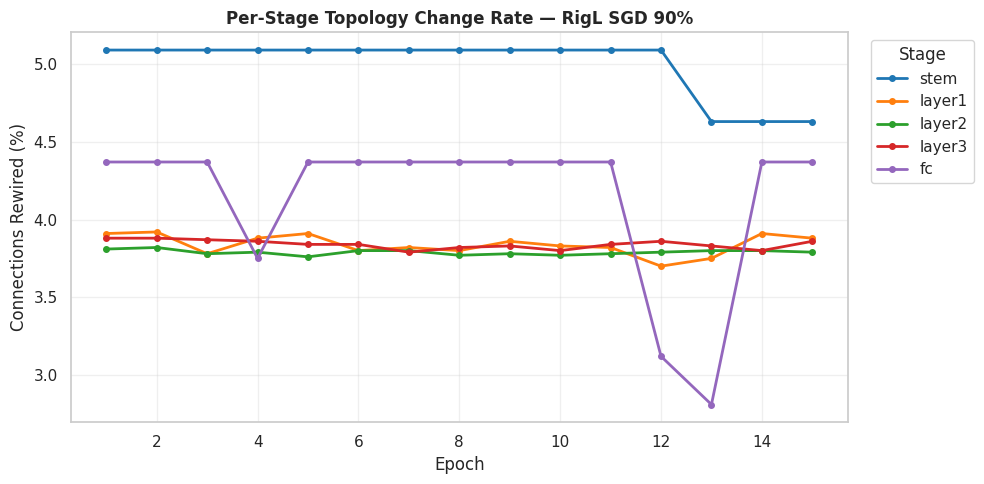

RigL connectivity evolution plot saved.


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = sns.color_palette("tab10", n_colors=len(evo_df.columns))
for col, color in zip(evo_df.columns, colors):
    ax.plot(
        evo_df.index,
        evo_df[col] * 100,
        marker="o",
        markersize=4,
        linewidth=2,
        label=col,
        color=color,
    )

ax.set_title("Per-Stage Topology Change Rate — RigL SGD 90%", weight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Connections Rewired (%)")
ax.legend(title="Stage", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    os.path.join(img_dir, "task_3_connectivity_evolution.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()
gc.collect()
print("RigL connectivity evolution plot saved.")

## 7. Topology Change Rate During Training — SET

Here we repeat the same topology change rate analysis for SET (SGD, 90% sparsity). Since SET grows connections randomly rather than by gradient magnitude, it has no information about which new connections will be useful — so it is expected to keep rewiring at a higher rate throughout training, as the random choices rarely produce connections the network wants to keep.

In [17]:
def set_update(model, masks, prune_fraction):
    """SET topology update: prune smallest-magnitude active weights, regrow randomly."""
    with torch.no_grad():
        for name, param in model.named_parameters():
            if name not in masks:
                continue
            mask = masks[name]
            active_pos = mask.nonzero(as_tuple=False)
            if active_pos.numel() == 0:
                continue

            n_update = int(active_pos.size(0) * prune_fraction)
            if n_update < 1:
                continue

            active_vals = param[mask.bool()].abs()
            _, prune_local_idx = torch.topk(active_vals, k=n_update, largest=False)
            prune_pos = active_pos[prune_local_idx]
            prune_idx = tuple(prune_pos[:, d] for d in range(prune_pos.size(1)))
            mask[prune_idx] = 0.0
            param[prune_idx] = 0.0

            inactive_pos = (mask == 0).nonzero(as_tuple=False)
            if inactive_pos.numel() == 0:
                continue
            n_grow = min(n_update, inactive_pos.size(0))
            rand_idx = torch.randperm(inactive_pos.size(0))[:n_grow]
            grow_pos = inactive_pos[rand_idx]
            grow_idx = tuple(grow_pos[:, d] for d in range(grow_pos.size(1)))
            mask[grow_idx] = 1.0
            param[grow_idx] = 0.0


# Re-run SET SGD 90% tracking per-stage topology change rate each epoch.
torch.manual_seed(42)
set_evo_model, set_evo_masks = build_sparse_model(0.90)
set_evo_optimizer = build_optimizer(set_evo_model, "sgd")
set_evo_history = []

for epoch in range(epochs):
    set_evo_model.train()
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        set_evo_optimizer.zero_grad()
        loss = criterion(set_evo_model(inputs), labels)
        loss.backward()
        apply_masks_to_grads(set_evo_model, set_evo_masks)
        set_evo_optimizer.step()
        apply_masks(set_evo_model, set_evo_masks)

    # Snapshot masks before topology update
    masks_before = {name: mask.clone() for name, mask in set_evo_masks.items()}

    if (epoch + 1) % rewire_interval == 0:
        set_update(set_evo_model, set_evo_masks, prune_fraction)
        apply_masks(set_evo_model, set_evo_masks)

    # Compute per-stage change rate
    stage_changed = {}
    stage_total = {}
    for name, mask in set_evo_masks.items():
        stage = get_stage(name)
        flipped = (mask.cpu() != masks_before[name].cpu()).float().sum().item()
        stage_changed[stage] = stage_changed.get(stage, 0.0) + flipped
        stage_total[stage] = stage_total.get(stage, 0) + mask.numel()

    record = {"epoch": epoch + 1}
    for stage in stage_changed:
        record[stage] = round(stage_changed[stage] / stage_total[stage], 4)
    set_evo_history.append(record)

    print(
        f"Epoch {epoch + 1:2d}/{epochs} — "
        + "  ".join(f"{k}: {v:.4f}" for k, v in record.items() if k != "epoch")
    )

set_evo_df = pd.DataFrame(set_evo_history).set_index("epoch")
print("\nSET connectivity evolution run complete.")

Epoch  1/15 — stem: 0.0509  layer1: 0.0383  layer2: 0.0379  layer3: 0.0386  fc: 0.0437
Epoch  2/15 — stem: 0.0509  layer1: 0.0388  layer2: 0.0377  layer3: 0.0384  fc: 0.0406
Epoch  3/15 — stem: 0.0509  layer1: 0.0383  layer2: 0.0380  layer3: 0.0386  fc: 0.0406
Epoch  4/15 — stem: 0.0509  layer1: 0.0383  layer2: 0.0382  layer3: 0.0385  fc: 0.0437
Epoch  5/15 — stem: 0.0509  layer1: 0.0385  layer2: 0.0379  layer3: 0.0387  fc: 0.0437
Epoch  6/15 — stem: 0.0509  layer1: 0.0388  layer2: 0.0381  layer3: 0.0386  fc: 0.0437
Epoch  7/15 — stem: 0.0509  layer1: 0.0383  layer2: 0.0381  layer3: 0.0385  fc: 0.0375
Epoch  8/15 — stem: 0.0509  layer1: 0.0386  layer2: 0.0381  layer3: 0.0386  fc: 0.0437
Epoch  9/15 — stem: 0.0509  layer1: 0.0383  layer2: 0.0380  layer3: 0.0385  fc: 0.0437
Epoch 10/15 — stem: 0.0509  layer1: 0.0380  layer2: 0.0379  layer3: 0.0387  fc: 0.0406
Epoch 11/15 — stem: 0.0509  layer1: 0.0388  layer2: 0.0378  layer3: 0.0386  fc: 0.0437
Epoch 12/15 — stem: 0.0509  layer1: 0.0389 

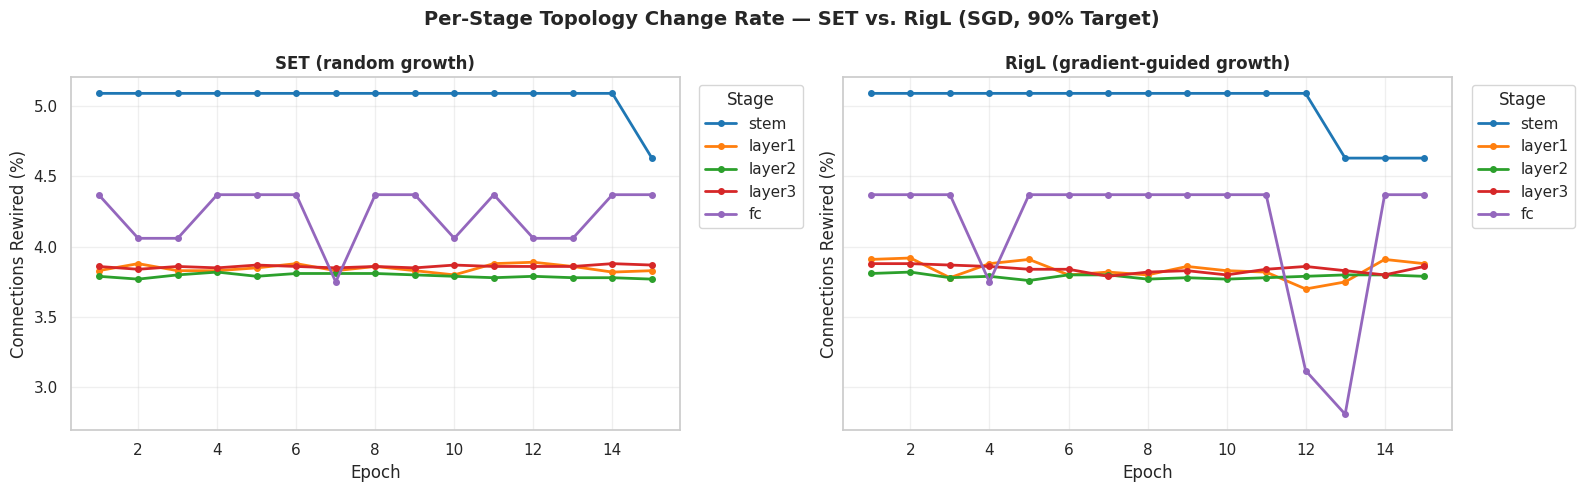

SET vs. RigL topology change rate plot saved.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
fig.suptitle(
    "Per-Stage Topology Change Rate — SET vs. RigL (SGD, 90% Target)",
    fontsize=14,
    weight="bold",
)

for ax, df, title in [
    (axes[0], set_evo_df, "SET (random growth)"),
    (axes[1], evo_df, "RigL (gradient-guided growth)"),
]:
    colors = sns.color_palette("tab10", n_colors=len(df.columns))
    for col, color in zip(df.columns, colors):
        ax.plot(
            df.index,
            df[col] * 100,
            marker="o",
            markersize=4,
            linewidth=2,
            label=col,
            color=color,
        )
    ax.set_title(title, weight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Connections Rewired (%)")
    ax.legend(title="Stage", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    os.path.join(img_dir, "task_3_set_vs_rigl_connectivity_evolution.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()
gc.collect()
print("SET vs. RigL topology change rate plot saved.")